In [1]:
import sys
sys.path.insert(0, "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code")
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
optuna_model_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/"
multiSeed_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/"
OUTPUT_DIR = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data"
MULTISEED_SEEDS = [42, 12587, 161287, 227745, 228796, 23698, 321456, 586231]
OPTUNA_SEED = 198716
specific_pairs = [
    {'drug_name': 'DAPORINAD', 'target': 'NAMPT'},
    {'drug_name': 'AZD8931', 'target': 'ERBB2'},
    {'drug_name': 'BMS-754807', 'target': 'IGF1R'},
    {'drug_name': 'DABRAFENIB', 'target': 'BRAF'},
    {'drug_name': 'IMATINIB', 'target': 'MCL1'},
    {'drug_name': 'MK-2206', 'target': 'AKT1'},
    {'drug_name': 'TIVANTINIB', 'target': 'MET'},
    {'drug_name': 'ULIXERTINIB', 'target': 'MAPK1'},
    {'drug_name': 'UPROSERTIB', 'target': 'AKT1'},
]
def load_model_and_data(drug_name, target, model_path):
    print(f"    Loading model from {model_path}")
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    print(f"    Loading data files...")
    exp_data = pd.read_csv(model.exp_path, header=0, index_col=0)
    dep_data = pd.read_csv(model.dep_path, header=0, index_col=0)
    ic50_data = pd.read_csv(model.ic50_path, header=0, index_col=0).T
    common_cellLines = sorted(
        set(exp_data.index) & set(dep_data.index) & set(ic50_data.index)
    )
    exp_data_subset = exp_data.loc[common_cellLines, model.hcg_list].drop_duplicates(keep='first')
    dep_target = dep_data.loc[common_cellLines, model.target].dropna().drop_duplicates(keep='first')
    drug_ic50_all = ic50_data.loc[dep_target.index, model.drug]
    valid_idx = drug_ic50_all.dropna().index
    dep_target = dep_target.loc[valid_idx]
    drug_ic50 = ic50_data.loc[valid_idx, model.drug]
    exp_data_subset = exp_data.loc[dep_target.index, model.hcg_list]
    print(f"    Data loaded: {len(exp_data_subset)} samples, {exp_data_subset.shape[1]} features")
    return model, exp_data_subset, dep_target, drug_ic50
def run_single_evaluation(model, exp_data_subset, dep_target, drug_ic50, seed):
    E = exp_data_subset.values
    D = dep_target.values.ravel()
    I = drug_ic50.values.ravel()
    valid_mask = ~(np.isnan(I) | np.isnan(D))
    E = E[valid_mask]
    D = D[valid_mask]
    I = I[valid_mask]
    W = model.W
    train_idx, test_idx = train_test_split(np.arange(len(E)), test_size=0.2, random_state=seed)
    E_train, E_test = E[train_idx], E[test_idx]
    D_train, D_test = D[train_idx], D[test_idx]
    I_train, I_test = I[train_idx], I[test_idx]
    E_mean = E_train.mean(axis=0)
    E_std = E_train.std(axis=0)
    E_std[E_std == 0] = 1
    E_train_norm = (E_train - E_mean) / E_std
    E_test_norm = (E_test - E_mean) / E_std
    D_train_mean = D_train.mean()
    I_train_mean = I_train.mean()
    D_train_centered = D_train - D_train_mean
    I_train_centered = I_train - I_train_mean
    D_test_centered = D_test - D_train_mean
    I_test_centered = I_test - I_train_mean
    Z_train = E_train_norm @ W
    Z_test = E_test_norm @ W
    try:
        h_I = np.linalg.pinv(Z_train.T @ Z_train + 1e-6 * np.eye(Z_train.shape[1])) @ Z_train.T @ I_train_centered
        h_D = np.linalg.pinv(Z_train.T @ Z_train + 1e-6 * np.eye(Z_train.shape[1])) @ Z_train.T @ D_train_centered
    except:
        h_I = np.zeros(W.shape[1])
        h_D = np.zeros(W.shape[1])
    pred_I_train = Z_train @ h_I
    pred_D_train = Z_train @ h_D
    pred_I_test = Z_test @ h_I
    pred_D_test = Z_test @ h_D
    train_corr_I = pearsonr(pred_I_train.flatten(), I_train_centered.flatten())[0] if np.std(pred_I_train) > 0 else np.nan
    test_corr_I = pearsonr(pred_I_test.flatten(), I_test_centered.flatten())[0] if np.std(pred_I_test) > 0 else np.nan
    train_corr_D = pearsonr(pred_D_train.flatten(), D_train_centered.flatten())[0] if np.std(pred_D_train) > 0 else np.nan
    test_corr_D = pearsonr(pred_D_test.flatten(), D_test_centered.flatten())[0] if np.std(pred_D_test) > 0 else np.nan
    return {
        'train_corr_I': train_corr_I,
        'test_corr_I': test_corr_I,
        'train_corr_D': train_corr_D,
        'test_corr_D': test_corr_D
    }
all_rows = []
for idx, pair in enumerate(specific_pairs):
    drug_name = pair['drug_name']
    target = pair['target']
    drug_upper = drug_name.upper()
    target_upper = target.upper()
    print(f"[{idx+1}/{len(specific_pairs)}] Processing {drug_name} - {target}...")
    model, exp_data_subset, dep_target, drug_ic50 = None, None, None, None
    data_loaded = False
    for seed_idx, seed in enumerate(MULTISEED_SEEDS):
        model_filename = f"{drug_upper}_{target_upper}_forgeModel_optuna100_{seed}.pkl"
        model_path = multiSeed_path + model_filename
        if not os.path.exists(model_path):
            print(f"  WARNING: Model not found for seed {seed}: {model_filename}")
            continue
        if not data_loaded:
            try:
                model, exp_data_subset, dep_target, drug_ic50 = load_model_and_data(drug_name, target, model_path)
                data_loaded = True
            except Exception as e:
                print(f"  ERROR loading data: {e}")
                break
        print(f"  Seed {seed} ({seed_idx+1}/{len(MULTISEED_SEEDS)+1})...")
        try:
            result = run_single_evaluation(model, exp_data_subset, dep_target, drug_ic50, seed)
            all_rows.append({
                'Drug': drug_name,
                'Target': target,
                'Seed': seed,
                'Train_IC50_r': result['train_corr_I'],
                'Test_IC50_r': result['test_corr_I'],
                'Train_Dependency_r': result['train_corr_D'],
                'Test_Dependency_r': result['test_corr_D']
            })
            print(f"    Done - Train Dep: {result['train_corr_D']:.3f}, Test Dep: {result['test_corr_D']:.3f}, Test IC50: {result['test_corr_I']:.3f}")
        except Exception as e:
            print(f"    ERROR: {e}")
    optuna_model_filename = f"{drug_upper}_{target_upper}_forgeModel_optuna100.pkl"
    optuna_model_path_full = optuna_model_path + optuna_model_filename
    if os.path.exists(optuna_model_path_full):
        print(f"  Seed {OPTUNA_SEED} ({len(MULTISEED_SEEDS)+1}/{len(MULTISEED_SEEDS)+1}) - optuna model...")
        try:
            if not data_loaded:
                model, exp_data_subset, dep_target, drug_ic50 = load_model_and_data(drug_name, target, optuna_model_path_full)
                data_loaded = True
            result = run_single_evaluation(model, exp_data_subset, dep_target, drug_ic50, OPTUNA_SEED)
            all_rows.append({
                'Drug': drug_name,
                'Target': target,
                'Seed': OPTUNA_SEED,
                'Train_IC50_r': result['train_corr_I'],
                'Test_IC50_r': result['test_corr_I'],
                'Train_Dependency_r': result['train_corr_D'],
                'Test_Dependency_r': result['test_corr_D']
            })
            print(f"    Done - Train Dep: {result['train_corr_D']:.3f}, Test Dep: {result['test_corr_D']:.3f}, Test IC50: {result['test_corr_I']:.3f}")
        except Exception as e:
            print(f"    ERROR: {e}")
    else:
        print(f"  WARNING: Optuna model not found: {optuna_model_filename}")
results_df = pd.DataFrame(all_rows)
output_path = os.path.join(OUTPUT_DIR, "Fig_7c.csv")
results_df.to_csv(output_path, index=False)
print(f"\n=== Summary ===")
print(f"Total rows: {len(results_df)}")
print(f"Columns: {results_df.columns.tolist()}")
print(f"\nSeeds evaluated: {sorted(results_df['Seed'].unique())}")
print(f"\nSamples per drug-target pair:")
print(results_df.groupby(['Drug', 'Target']).size())
print(f"\nFig_7c.csv saved to: {output_path}")

[1/9] Processing DAPORINAD - NAMPT...
    Loading model from /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/DAPORINAD_NAMPT_forgeModel_optuna100_42.pkl
    Loading data files...
    Data loaded: 647 samples, 199 features
  Seed 42 (1/9)...
    Done - Train Dep: 0.539, Test Dep: 0.599, Test IC50: 0.517
  Seed 12587 (2/9)...
    Done - Train Dep: 0.559, Test Dep: 0.475, Test IC50: 0.569
  Seed 161287 (3/9)...
    Done - Train Dep: 0.552, Test Dep: 0.541, Test IC50: 0.554
  Seed 227745 (4/9)...
    Done - Train Dep: 0.550, Test Dep: 0.558, Test IC50: 0.531
  Seed 228796 (5/9)...
    Done - Train Dep: 0.568, Test Dep: 0.481, Test IC50: 0.592
  Seed 23698 (6/9)...
    Done - Train Dep: 0.558, Test Dep: 0.538, Test IC50: 0.530
  Seed 321456 (7/9)...
    Done - Train Dep: 0.539, Test Dep: 0.597, Test IC50: 0.553
  Seed 586231 (8/9)...
    Done - Train Dep: 0.548, Test Dep: 0.560, Test IC50: 0.511
  Seed 19871

=== Summary ===
                  label  test_dep_mean  test_ic50_mean
0    DAPORINAD\n(NAMPT)       0.549492        0.545270
1      AZD8931\n(ERBB2)       0.438310        0.416040
2   BMS-754807\n(IGF1R)       0.460506        0.545895
3    DABRAFENIB\n(BRAF)       0.573845        0.616000
4      IMATINIB\n(MCL1)       0.402999        0.474261
5       MK-2206\n(AKT1)       0.362325        0.535650
6     TIVANTINIB\n(MET)       0.189847        0.695045
7  ULIXERTINIB\n(MAPK1)       0.376861        0.606359
8    UPROSERTIB\n(AKT1)       0.300969        0.457013


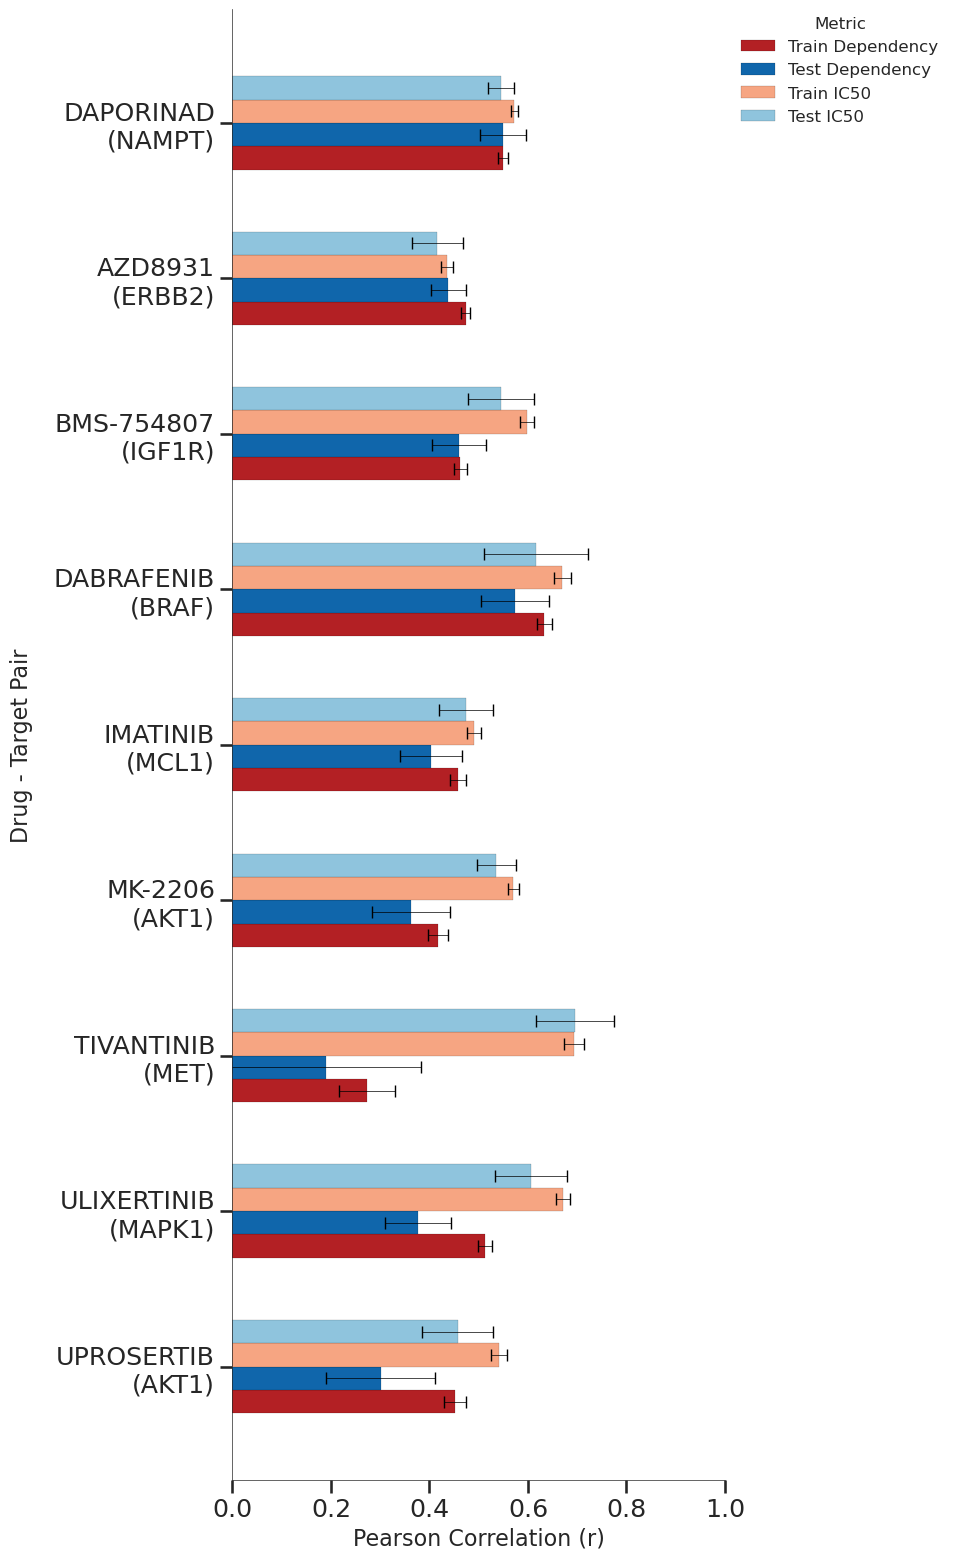


Figure saved to: /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig7c_model_comparison.pdf


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
sns.set(style="ticks", context="talk", font_scale=1.1)
COLOR_TRAIN_IC50 = '#F6A582'
COLOR_TEST_IC50 = '#8FC4DD'
COLOR_TRAIN_DEP = '#B32024'
COLOR_TEST_DEP = '#1066AB'
specific_pairs = [
    {'drug_name': 'DAPORINAD', 'target': 'NAMPT'},
    {'drug_name': 'AZD8931', 'target': 'ERBB2'},
    {'drug_name': 'BMS-754807', 'target': 'IGF1R'},
    {'drug_name': 'DABRAFENIB', 'target': 'BRAF'},
    {'drug_name': 'IMATINIB', 'target': 'MCL1'},
    {'drug_name': 'MK-2206', 'target': 'AKT1'},
    {'drug_name': 'TIVANTINIB', 'target': 'MET'},
    {'drug_name': 'ULIXERTINIB', 'target': 'MAPK1'},
    {'drug_name': 'UPROSERTIB', 'target': 'AKT1'},
]
input_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Fig_7c.csv"
df = pd.read_csv(input_path)
results = []
for pair in specific_pairs:
    drug = pair['drug_name']
    target = pair['target']
    subset = df[(df['Drug'] == drug) & (df['Target'] == target)]
    if len(subset) == 0:
        continue
    results.append({
        "label": f"{drug}\n({target})",
        "train_ic50_mean": subset['Train_IC50_r'].mean(),
        "train_ic50_std": subset['Train_IC50_r'].std(),
        "test_ic50_mean": subset['Test_IC50_r'].mean(),
        "test_ic50_std": subset['Test_IC50_r'].std(),
        "train_dep_mean": subset['Train_Dependency_r'].mean(),
        "train_dep_std": subset['Train_Dependency_r'].std(),
        "test_dep_mean": subset['Test_Dependency_r'].mean(),
        "test_dep_std": subset['Test_Dependency_r'].std(),
    })
final_df = pd.DataFrame(results)
order_map = {f"{p['drug_name']}\n({p['target']})": i for i, p in enumerate(specific_pairs)}
final_df['order'] = final_df['label'].map(order_map)
final_df = final_df.sort_values('order').reset_index(drop=True)
final_df = final_df.drop('order', axis=1)
print("=== Summary ===")
print(final_df[['label', 'test_dep_mean', 'test_ic50_mean']])
fig, ax = plt.subplots(figsize=(10, 16))
bar_height = 0.15
group_indices = np.arange(len(final_df))
offsets = [1.5 * bar_height, 0.5 * bar_height, -0.5 * bar_height, -1.5 * bar_height]
palette = {
    "Train Dependency": COLOR_TRAIN_DEP,
    "Test Dependency": COLOR_TEST_DEP,
    "Train IC50": COLOR_TRAIN_IC50,
    "Test IC50": COLOR_TEST_IC50
}
plot_data = pd.DataFrame()
for metric in ["Train Dependency", "Test Dependency", "Train IC50", "Test IC50"]:
    if metric == "Train Dependency":
        mean_col, std_col = "train_dep_mean", "train_dep_std"
    elif metric == "Test Dependency":
        mean_col, std_col = "test_dep_mean", "test_dep_std"
    elif metric == "Train IC50":
        mean_col, std_col = "train_ic50_mean", "train_ic50_std"
    else:
        mean_col, std_col = "test_ic50_mean", "test_ic50_std"
    temp_df = final_df[[mean_col, std_col]].copy()
    temp_df["Metric"] = metric
    temp_df["Mean"] = temp_df[mean_col]
    temp_df["SD"] = temp_df[std_col]
    temp_df = temp_df.reset_index()
    plot_data = pd.concat([plot_data, temp_df], ignore_index=True)
for metric_idx, metric in enumerate(["Train Dependency", "Test Dependency", "Train IC50", "Test IC50"]):
    metric_data = plot_data[plot_data["Metric"] == metric]
    ax.barh(
        group_indices + offsets[metric_idx],
        metric_data["Mean"],
        xerr=metric_data["SD"],
        height=bar_height,
        label=metric,
        color=palette[metric],
        capsize=4,
        edgecolor='black',
        linewidth=0.1,
        ecolor='black',
        error_kw=dict(linewidth=0.5)
    )
ax.set_ylabel('Drug - Target Pair', fontsize=16, labelpad=15)
ax.set_xlabel('Pearson Correlation (r)', fontsize=16)
ax.legend(
    title="Metric",
    fontsize=12,
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False
)
ax.set_yticks(group_indices)
ax.set_yticklabels(final_df["label"], fontsize=12)
ax.invert_yaxis()
ax.set_xticks(np.arange(0, 1.1, 0.2))
ax.set_xlim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
fig.tight_layout()
output_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig7c_model_comparison.pdf"
#fig.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
print(f"\nFigure saved to: {output_path}")